In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma


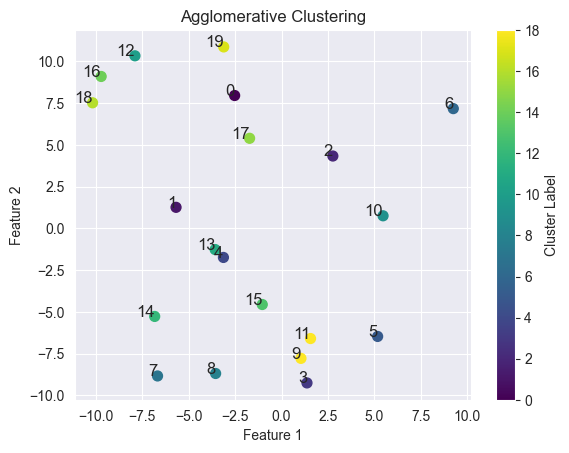

In [7]:
#X = np.random.uniform(-1, 1, size=(4, 2))
X, y = make_blobs(n_samples=20, centers=19, cluster_std=1,random_state=42)
n=30
p=2
sigma=1
mu = np.zeros(p)  
#X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=19,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [8]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent

In [2]:
n = X.shape[0]
def compute_nu(node):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def compute_dirT(w):
    # return dir(w)^T
    norm = np.linalg.norm(w)
    dir_w = (w / norm) if norm != 0 else np.zeros_like(w)
    return dir_w.T
nu = compute_nu(node)

nuisance = (np.eye(n) - np.outer(nu,nu)/np.linalg.norm(nu)**2) @ X
contrast = X.T@nu
dir = compute_dirT(X.T@nu)
ngrid=100
grid_width=15
stat_grid = np.linspace(0.0001, grid_width, num=ngrid)

NameError: name 'X' is not defined

In [10]:
model._condl_approx_log_reference(node,stat_grid,nuisance,contrast,)

level:  1


(array([ -0.47521377,  -0.472434  ,  -0.46935752,  -0.46598946,
         -0.46233493,  -0.4583991 ,  -0.4541873 ,  -0.44970505,
         -0.44495819,  -0.43995293,  -0.43469589,  -0.4291942 ,
         -0.42345549,  -0.41748798,  -0.41130047,  -0.40490237,
         -0.39830371,  -0.39151508,  -0.3845477 ,  -0.37741328,
         -0.37012409,  -0.36269284,  -0.35513267,  -0.34745707,
         -0.33967986,  -0.33181513,  -0.32387718,  -0.31588047,
         -0.30783958,  -0.29976919,  -0.29168398,  -0.28359866,
         -0.27552793,  -0.26748638,  -0.26234751,  -0.27110769,
         -0.294964  ,  -0.33402017,  -0.38835772,  -0.45804012,
         -0.5430999 ,  -0.64346582,  -0.75913934,  -0.89013243,
         -1.03645005,  -1.19809131,  -1.37505029,  -1.56731682,
         -1.77487695,  -1.99771345,  -2.23580607,  -2.48913173,
         -2.75766455,  -3.0413758 ,  -3.34023354,  -3.65420214,
         -3.98324129,  -4.32730453,  -4.68633698,  -5.06027182,
         -5.44902521,  -5.85248989,  -6.

In [11]:
model.condl_merge_inference(node)

level:  1


(np.float64(0.5831624669825161),
 np.float64(0.9152717076792818),
 array([  -82.04017935,   -81.89928142,   -81.76061845,   -81.62419044,
          -81.4899974 ,   -81.35803931,   -81.22831619,   -81.10082804,
          -80.97557484,   -80.85255661,   -80.73177334,   -80.61322503,
          -80.49691169,   -80.38283331,   -80.27098989,   -80.16138143,
          -80.05400793,   -79.9488694 ,   -79.84596583,   -79.74529722,
          -79.64686358,   -79.5506649 ,   -79.45670118,   -79.36497242,
          -79.27547862,   -79.18821979,   -79.10319592,   -79.02040701,
          -78.93985307,   -78.86153408,   -78.78545006,   -78.711601  ,
          -78.63998691,   -78.57060778,   -78.50346361,   -78.4385544 ,
          -78.37588015,   -78.31544087,   -78.25723655,   -78.20126719,
          -78.14753279,   -78.09603336,   -78.04676889,   -77.99973938,
          -77.95494484,   -77.91238525,   -77.87206063,   -77.83397097,
          -77.79811628,   -77.76449654,   -77.73311177,   -77.70396196

In [3]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def naive_p_value(X, node, sigma=1,grid_width=25,ngrid= 1000):
    from scipy.stats import chi
    n = np.shape(X)[0]
    p = np.shape(X)[1]
    nu = compute_nu(node,n).reshape(-1,1)
    #obs_target = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sigma)
    # Extract cluster indices
    left_indices = node.left.points
    right_indices = node.right.points

    # Compute cluster means
    left_mean = np.mean(X[left_indices, :], axis=0)
    right_mean = np.mean(X[right_indices, :], axis=0)

    # Compute the Euclidean distance between cluster means
    obs_target = np.linalg.norm(left_mean - right_mean)

    # Compute the scaling factor
    n_left = len(left_indices)
    n_right = len(right_indices)
    scale_factor = sigma * np.sqrt(1 / n_left + 1 / n_right)
    '''
    stat_grid = np.linspace(0.00001, grid_width,
                                    num=ngrid)
    logWeights = np.zeros((ngrid,)) 
    for g in range(ngrid):
        logWeights[g] = (- 0.5 * (stat_grid[g])** 2 + (p-1)*np.log(stat_grid[g])
                        - (p / 2 - 1) * np.log(2))
    logWeights = logWeights - np.max(logWeights)
    density = np.exp(logWeights)/gamma(p/2)
    sum = 0
    num = 0
    for g in range(ngrid):
        sum += density[g]
        if stat_grid[g] >= obs_target:
            num += density[g]
    p_value = num/sum
    '''
    p_value = 1 - chi.cdf(obs_target/scale_factor, df=p)
    return p_value

def check_p_value_uniformity(n,p, sigma, K, tau,layer, num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)  

    for _ in range(num_trials):
        X = generate_null_data(n,p,mu,sigma)
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K,linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs,sel= model.condl_merge_inference(node,grid_width= 20, ncoarse=20,ngrid = 1000,sd=sigma)
        p_value_n = naive_p_value(X,node)
        p_values.append(p_value)
        p_values_n.append(p_value_n)

    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


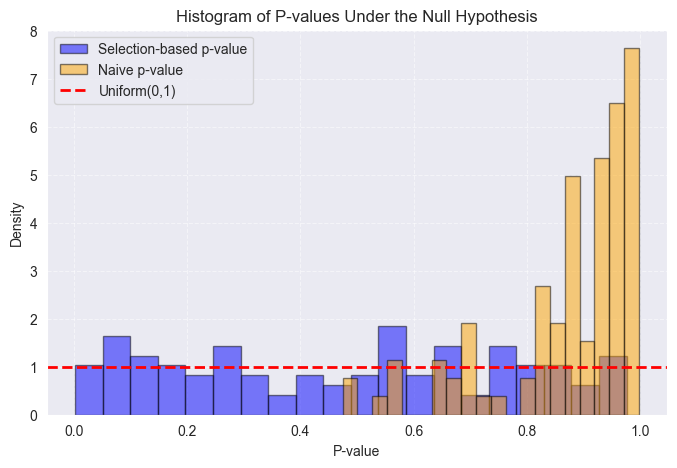

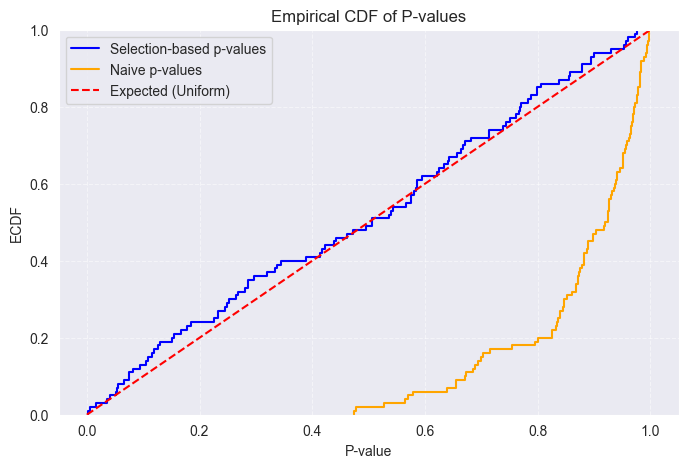

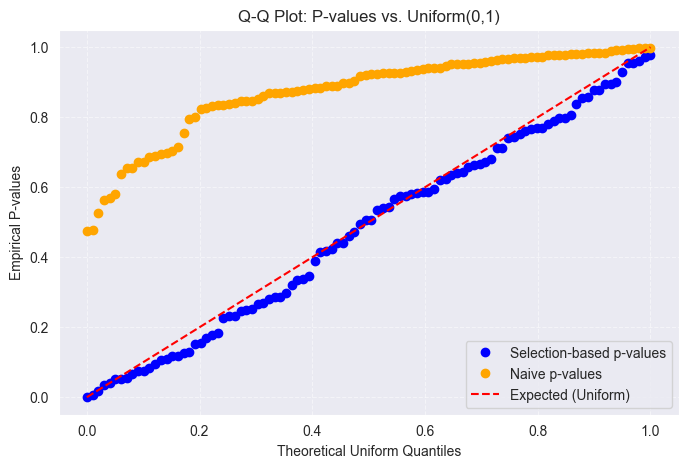

In [3]:
check_p_value_uniformity(20,2,1,19,1,-1,100)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


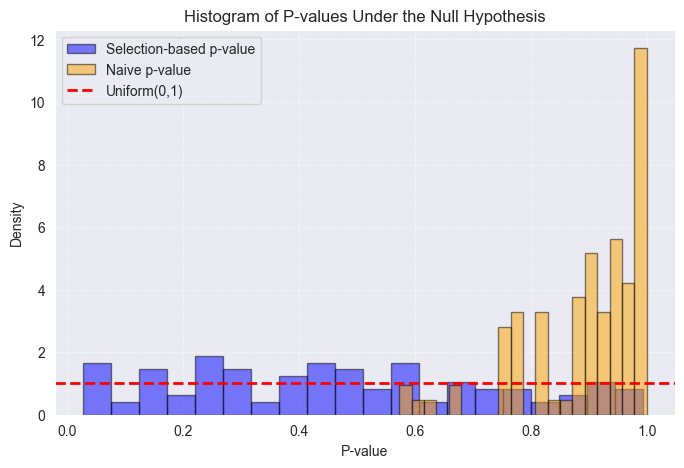

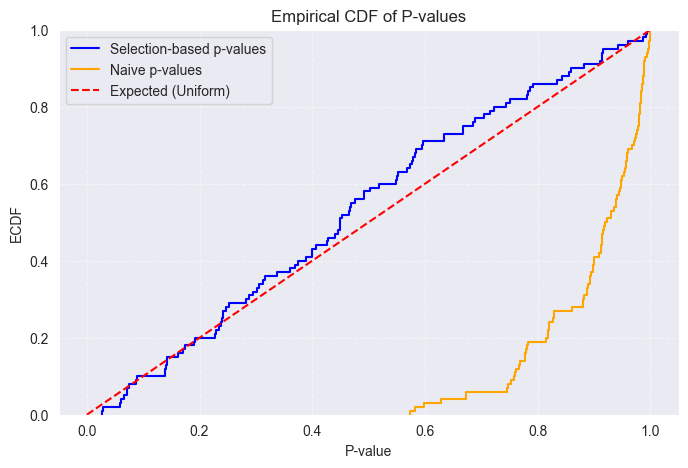

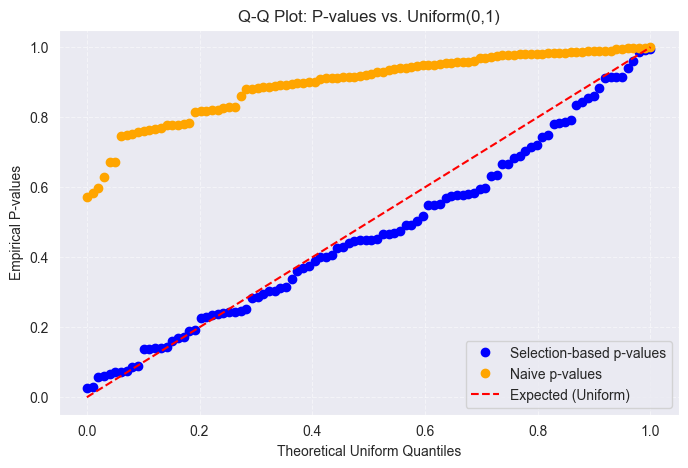

In [4]:
check_p_value_uniformity(30,2,1,29,1,-1,100)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


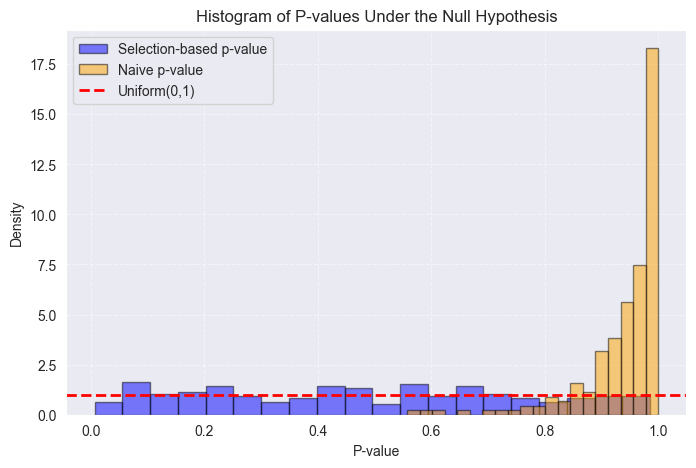

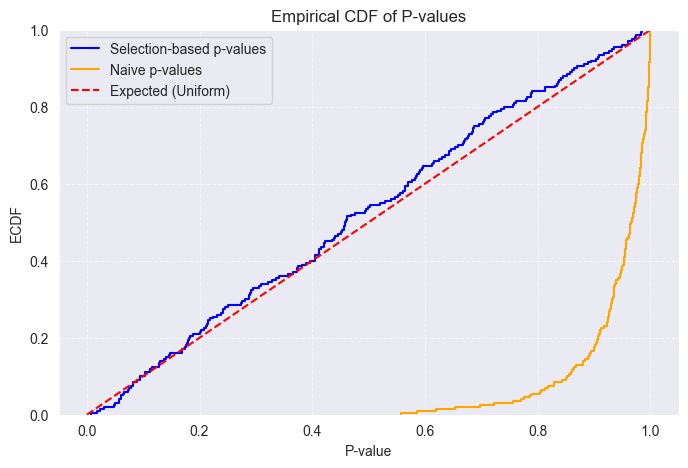

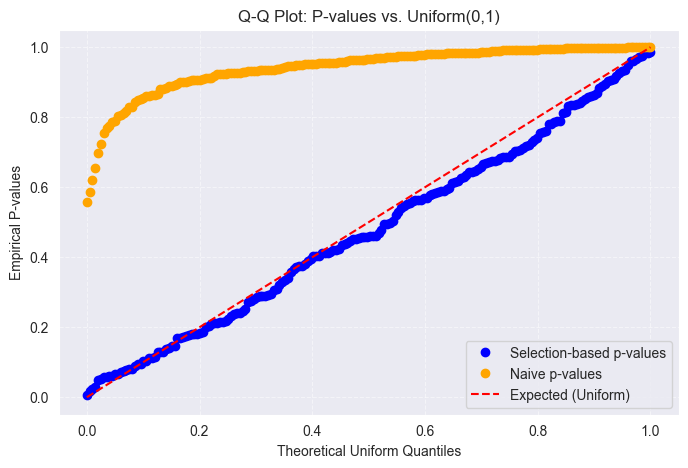

In [6]:
check_p_value_uniformity(30,15,1,29,1,-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


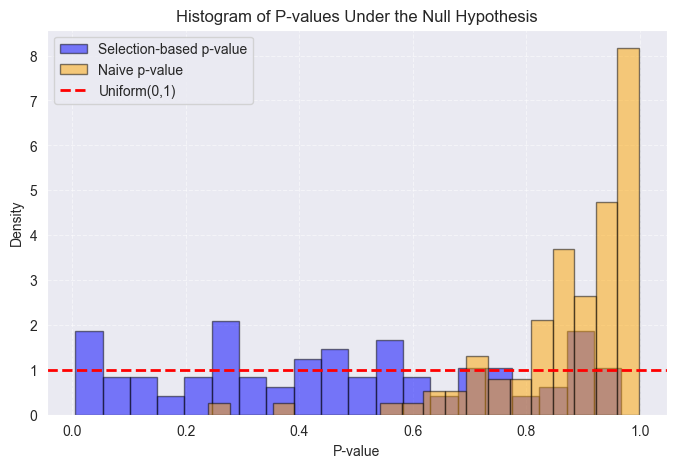

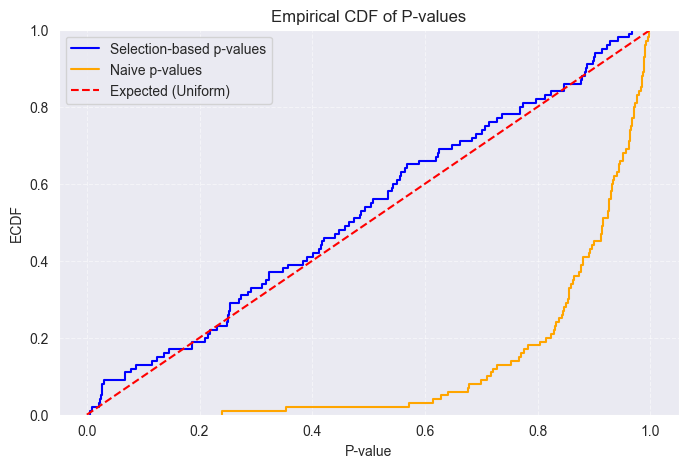

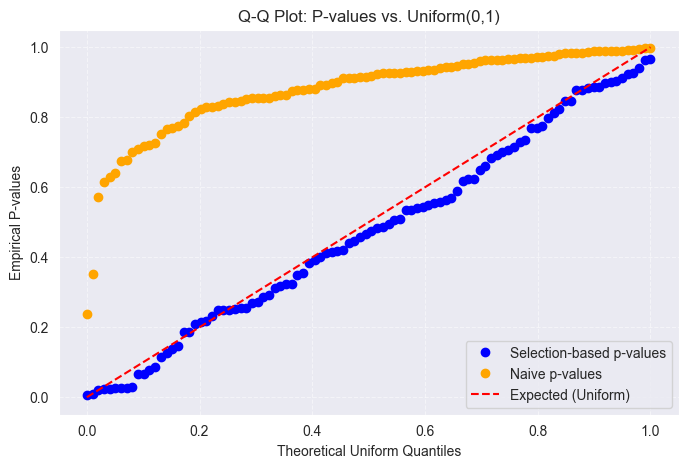

In [5]:
check_p_value_uniformity(50,2,1,49,1,-1,100)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


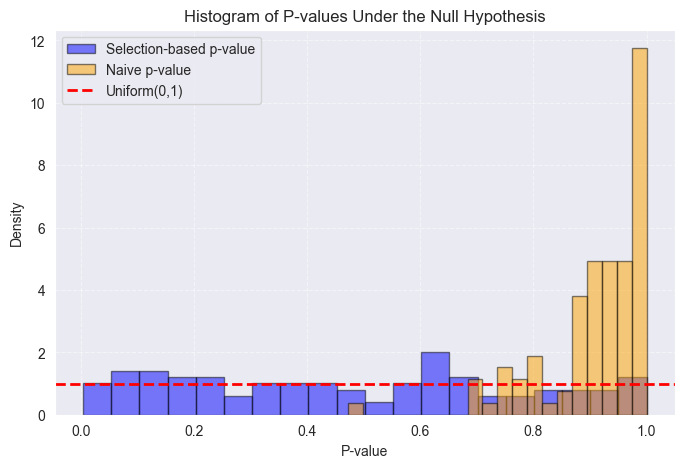

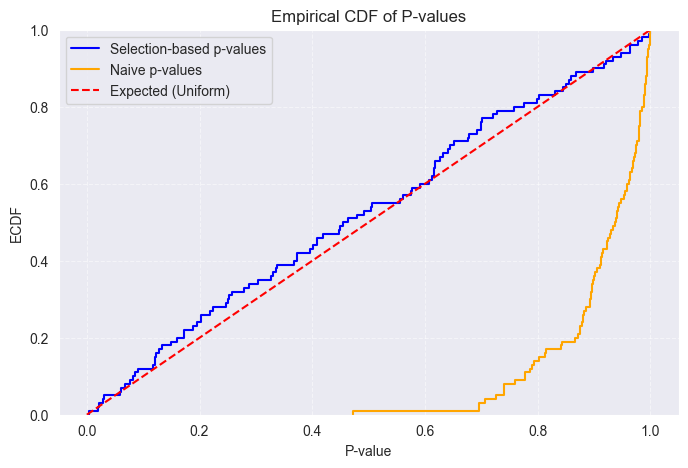

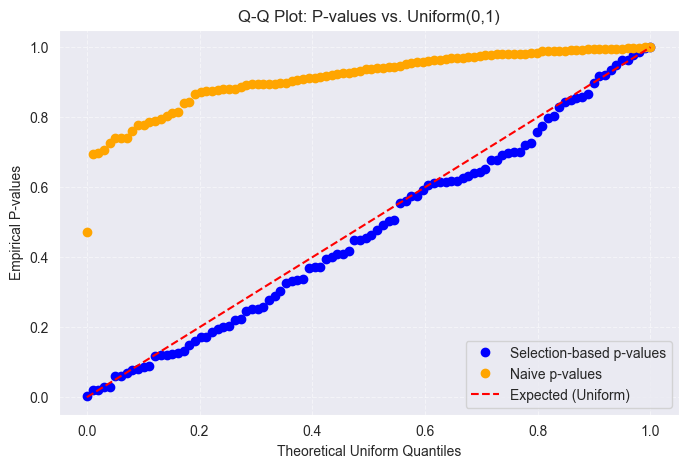

In [7]:
check_p_value_uniformity(70,2,1,69,1,-1,100)

level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:

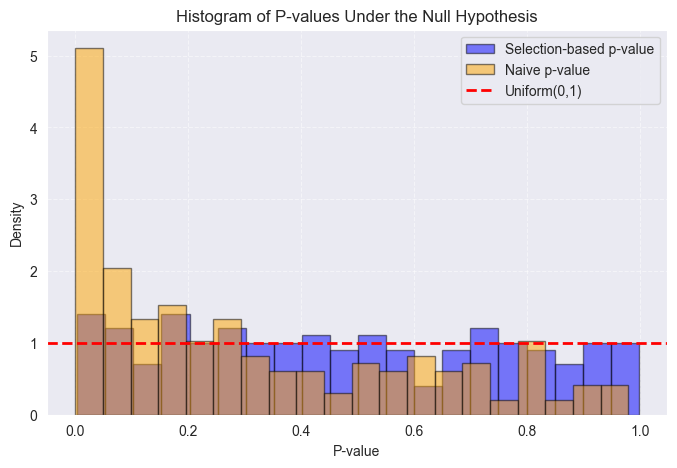

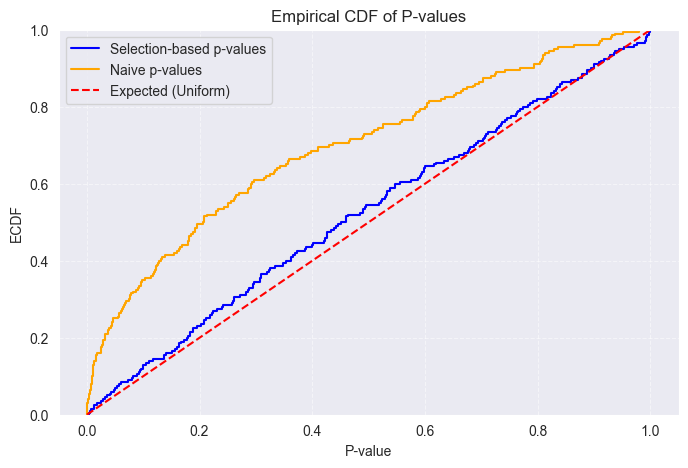

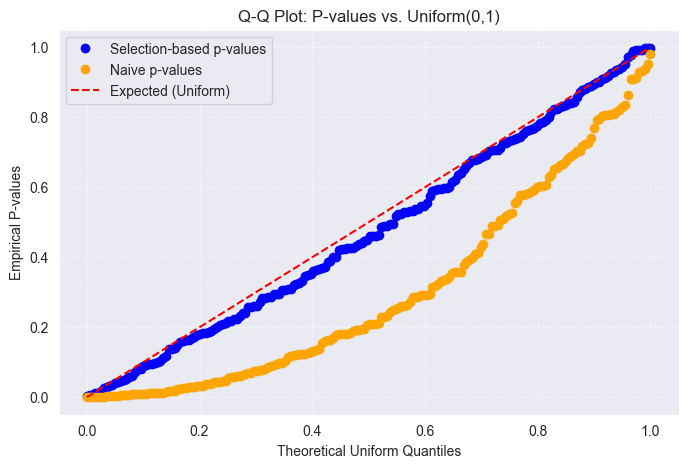

In [5]:
check_p_value_uniformity(30,2,1,5,1,-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


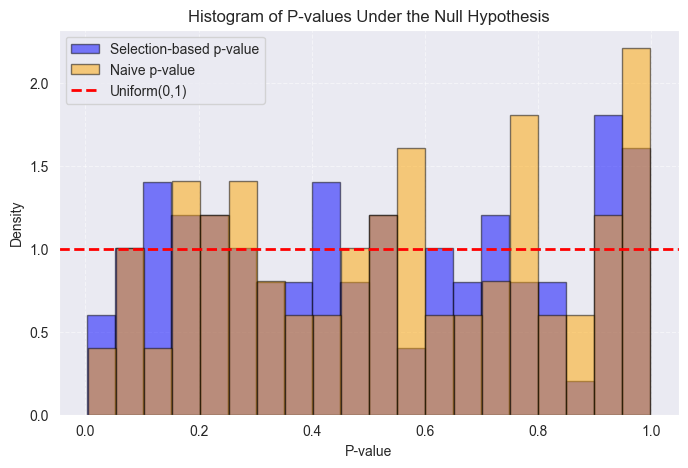

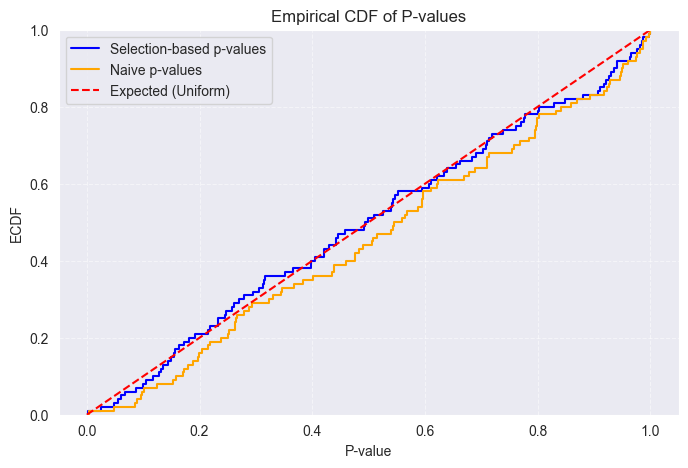

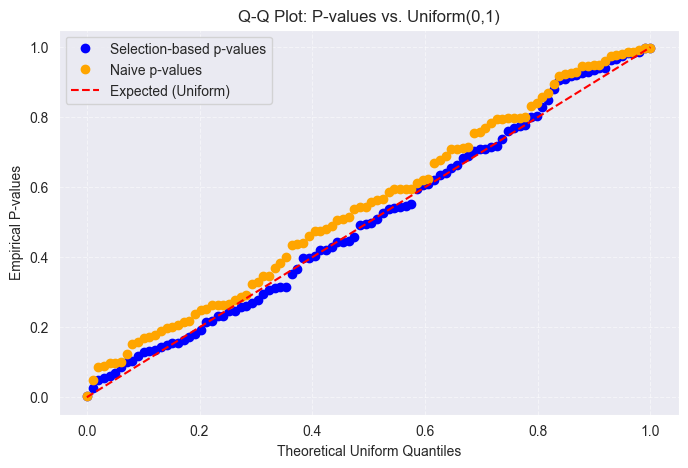

In [10]:
check_p_value_uniformity(30,20,1,29,20,-1,100)